In [ ]:
!pip install rouge

In [ ]:
import pandas as pd
#Ekstraksi fitur
import nltk
from nltk.tokenize import sent_tokenize
#Preprocessing
import re
from nltk.corpus import stopwords
#TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer, TfidfTransformer
#Cosine Similarity
from sklearn.metrics.pairwise import cosine_similarity
#Graph
import networkx as nx
import matplotlib.pyplot as plt
#Rouge
from rouge import Rouge

In [ ]:
nltk.download("punkt")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
csv_path = 'https://raw.githubusercontent.com/ach-Ilhamf/data_csv/main/data-berita.csv'
df = pd.read_csv(csv_path)
df.head(10)

,Judul,Tanggal,URL,Content,Kelas
0,Jadwal Siaran Langsung Championship Series Lig...,"Kompas.com - 13/05/2024, 05:28 WIB",https://bola.kompas.com/read/2024/05/13/052822...,"Pada fase Championship Series Liga 1 ini, empa...",OLAHRAGA
1,"Bantah Menang Pilpres Akibat Bansos, Prabowo: ...","Kompas.com - 13/05/2024, 05:15 WIB",https://nasional.kompas.com/read/2024/05/13/05...,Hal itu disampaikan Prabowo dalam wawancara kh...,NEWS
2,"Man United Vs Arsenal: Setan Merah Tumbang, Te...","Kompas.com - 13/05/2024, 05:00 WIB",https://bola.kompas.com/read/2024/05/13/050012...,Man United menelan kekalahan 0-1 setelah kebob...,OLAHRAGA
3,[POPULER NASIONAL] Reaksi Usai Prabowo Tak Mau...,"Kompas.com - 13/05/2024, 05:00 WIB",https://nasional.kompas.com/read/2024/05/13/05...,"Menurut Partai Gerindra, pernyataan Prabowo be...",NEWS
4,"Rute KA Dharmawangsa, Tarif dan Jadwalnya 2024","Kompas.com - 13/05/2024, 05:00 WIB",https://megapolitan.kompas.com/read/2024/05/13...,Kereta ini berangkat dari Stasiun Pasar Senen ...,NEWS
5,Studi: Gangguan Makan Pengaruhi 24 Persen Pend...,"Kompas.com - 13/05/2024, 05:00 WIB",https://health.kompas.com/read/24E13050000968/...,Diabetes tipe 1 adalah jenis diabetes yang bia...,HEALTH
6,Hasil-Klasemen Liga Italia: Juventus Tertahan ...,"Kompas.com - 13/05/2024, 04:33 WIB",https://bola.kompas.com/read/2024/05/13/043330...,Laga Juventus vs Salernitana pada pekan ke-36 ...,OLAHRAGA
7,"Man United Kalah dari Arsenal, Rooney dan Kean...","Kompas.com - 13/05/2024, 01:38 WIB",https://bola.kompas.com/read/2024/05/13/013857...,Arsenal menorehkan kemenangan di Old Trafford ...,OLAHRAGA
8,"Man United Kalah dari Arsenal, Atap Old Traffo...","Kompas.com - 13/05/2024, 01:08 WIB",https://bola.kompas.com/read/2024/05/13/010847...,Hasil Man United vs Arsenal usai dengan skor 0...,OLAHRAGA
9,Klasemen Premier League Usai Kemenangan Arsena...,"Kompas.com - 13/05/2024, 00:44 WIB",https://bola.kompas.com/read/2024/05/13/004454...,Arsenal memastikan kemenangan di Old Trafford ...,OLAHRAGA


In [ ]:
berita = df["Content"].iloc[0]
berita

'Pada fase Championship Series Liga 1 ini, empat tim teratas pada Reguler Series akan menjalani format semifinal dengan sistem kandang dan tandang.\nBabak ini akan mempertemukan Borneo FC Samarinda melawan Madura United dan Persib Bandung menghadapi Bali United.\nMadura United berkesempatan menjadi tuan rumah untuk kali pertama saat melawan Borneo FC, yang merupakan juara Reguler Series Liga 1.\nLaga Madura United vs Borneo FC akan berlangsung di Stadion Gelora Bangkalan pada Rabu (15/5/2024) pukul 19.00 WIB.\xa0\xa0\nAdapun leg kedua semifinal Borneo FC vs Madura United akan digelar di Stadion Batakan pada Minggu (19/5/2024).\nPada semifinal lainnya, Bali United akan menjamu Persib Bandung pada laga pertama di Bali United Training Center, Selasa (14/5/2024), pukul 19.00 WIB.\nLaga kedua antara Persib Bandung vs Bali United akan digelar di Stadion Si Jalak Harupat Bandung pada Sabtu (18/5/2024) pukul 19.00 WIB.\nSebelumnya, PT Liga Indonesia Baru (LIB) mengumumkan perubahan arena perta

# Tokenisasi Kalimat

In [ ]:
# Menghapus karakter khusus yang tidak terlihat seperti \xa0
berita = re.sub(r'\xa0', ' ', berita)
# Memisahkan teks menjadi kalimat
def sent_tokenize(teks):
    kalimat = re.split(r'(?<=[.!?])\s+', teks)
    return kalimat

kalimat_awal = sent_tokenize(berita)
kalimat_awal

['Pada fase Championship Series Liga 1 ini, empat tim teratas pada Reguler Series akan menjalani format semifinal dengan sistem kandang dan tandang.',
 'Babak ini akan mempertemukan Borneo FC Samarinda melawan Madura United dan Persib Bandung menghadapi Bali United.',
 'Madura United berkesempatan menjadi tuan rumah untuk kali pertama saat melawan Borneo FC, yang merupakan juara Reguler Series Liga 1.',
 'Laga Madura United vs Borneo FC akan berlangsung di Stadion Gelora Bangkalan pada Rabu (15/5/2024) pukul 19.00 WIB.',
 'Adapun leg kedua semifinal Borneo FC vs Madura United akan digelar di Stadion Batakan pada Minggu (19/5/2024).',
 'Pada semifinal lainnya, Bali United akan menjamu Persib Bandung pada laga pertama di Bali United Training Center, Selasa (14/5/2024), pukul 19.00 WIB.',
 'Laga kedua antara Persib Bandung vs Bali United akan digelar di Stadion Si Jalak Harupat Bandung pada Sabtu (18/5/2024) pukul 19.00 WIB.',
 'Sebelumnya, PT Liga Indonesia Baru (LIB) mengumumkan perubah

# Preprocessing

In [ ]:
# Membersihkan teks
def preprocess_text(teks):
    # Menghapus karakter non-alphanumeric kecuali spasi dan titik
    text_no_special_chars = re.sub(r'[^\w\s.]', '', teks)
    # Mengubah teks menjadi huruf kecil (lowecase)
    text_lowercase = text_no_special_chars.lower()

    # Menghapus stopwords
    stop_words = set(stopwords.words('indonesian'))
    stop_words.discard('tidak')
    words = text_lowercase.split()
    filtered_words = [word for word in words if word.lower() not in stop_words]
    return ' '.join(filtered_words)

kalimat_preprocessed = [preprocess_text(k) for k in kalimat_awal]
kalimat_preprocessed

['fase championship series liga 1 tim teratas reguler series menjalani format semifinal sistem kandang tandang.',
 'babak mempertemukan borneo fc samarinda melawan madura united persib bandung menghadapi bali united.',
 'madura united berkesempatan tuan rumah kali melawan borneo fc juara reguler series liga 1.',
 'laga madura united vs borneo fc stadion gelora bangkalan rabu 1552024 19.00 wib.',
 'leg semifinal borneo fc vs madura united digelar stadion batakan minggu 1952024.',
 'semifinal bali united menjamu persib bandung laga bali united training center selasa 1452024 19.00 wib.',
 'laga persib bandung vs bali united digelar stadion si jalak harupat bandung sabtu 1852024 19.00 wib.',
 'pt liga indonesia lib mengumumkan perubahan arena pertandingan laga leg championship series liga 1 bali united vs persib bandung.',
 'bali united dijadwalkan menjamu persib laga leg semifinal championship series liga 1 20232024 stadion kapten i wayan dipta gianyar.',
 'pindah bali united training cen

# TF-IDF

In [ ]:
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(kalimat_preprocessed)

terms = tfidf_vectorizer.get_feature_names_out()
tfidf = pd.DataFrame(data=tfidf_matrix.toarray(), columns=terms)
tfidf

,00,10,1452024,1552024,1852024,19,1952024,20232024,2024,619,...,terbaik,tim,training,tuan,u17,united,venue,vs,wayan,wib
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.287848,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.277569,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.33097,0.000000,0.129794,0.000000,0.000000,0.000000,0.000000
3,0.262801,0.000000,0.000000,0.339137,0.000000,0.262801,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.132996,0.000000,0.238226,0.000000,0.262801
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.367876,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.144267,0.000000,0.258414,0.000000,0.000000
5,0.253523,0.000000,0.327164,0.000000,0.000000,0.253523,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.284087,0.00000,0.000000,0.256603,0.000000,0.000000,0.000000,0.253523
6,0.227682,0.000000,0.000000,0.000000,0.293817,0.227682,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.115224,0.000000,0.206391,0.000000,0.227682
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.109603,0.000000,0.196323,0.000000,0.000000
8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.304992,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.119606,0.000000,0.000000,0.304992,0.000000
9,0.000000,0.301573,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.261865,0.00000,0.000000,0.118265,0.301573,0.000000,0.000000,0.000000


# Cosine Similarity

In [ ]:
# Menghitung cosine similarity antara semua pasangan kalimat
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Membuat DataFrame untuk cosine similarity
cosine_sim_df = pd.DataFrame(cosine_sim, columns=range(len(kalimat_preprocessed)), index=range(len(kalimat_preprocessed)))

# Menampilkan matriks cosine similarity
cosine_sim_df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,1.000000,0.000000,0.212860,0.000000,0.052251,0.046468,0.000000,0.207093,0.225995,0.000000,0.061266,0.000000,0.000000,0.000000,0.0
1,0.000000,1.000000,0.297728,0.214580,0.232764,0.229029,0.201315,0.142690,0.102454,0.057147,0.053492,0.067463,0.069746,0.000000,0.0
2,0.212860,0.297728,1.000000,0.183418,0.198961,0.033305,0.014955,0.151155,0.115142,0.015350,0.014368,0.018121,0.018735,0.000000,0.0
3,0.000000,0.214580,0.183418,1.000000,0.317052,0.273047,0.320288,0.094697,0.095099,0.051716,0.054334,0.018568,0.019197,0.000000,0.0
4,0.052251,0.232764,0.198961,0.317052,1.000000,0.096407,0.196178,0.128284,0.186416,0.017062,0.058938,0.020142,0.020824,0.000000,0.0
5,0.046468,0.229029,0.033305,0.273047,0.096407,1.000000,0.415005,0.184921,0.277036,0.258814,0.070496,0.088909,0.091918,0.000000,0.0
6,0.000000,0.201315,0.014955,0.320288,0.196178,0.415005,1.000000,0.215770,0.139889,0.064996,0.065973,0.039923,0.041274,0.000000,0.0
7,0.207093,0.142690,0.151155,0.094697,0.128284,0.184921,0.215770,1.000000,0.326349,0.061825,0.030111,0.037976,0.039261,0.000000,0.0
8,0.225995,0.102454,0.115142,0.095099,0.186416,0.277036,0.139889,0.326349,1.000000,0.136819,0.068482,0.041442,0.042844,0.000000,0.0
9,0.000000,0.057147,0.015350,0.051716,0.017062,0.258814,0.064996,0.061825,0.136819,1.000000,0.032491,0.040977,0.042364,0.000000,0.0


# Graph

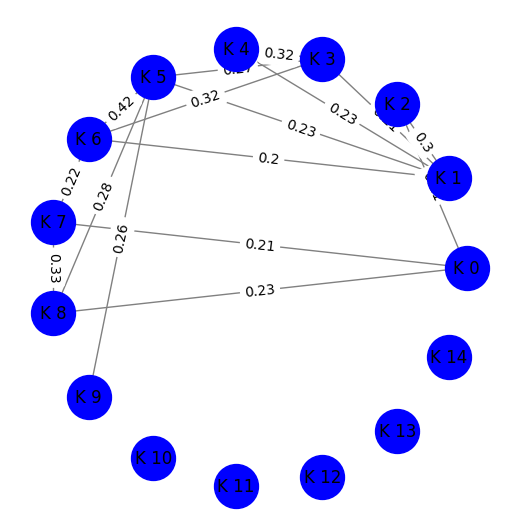

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

# Tambahkan node (kalimat)
for i in range(len(cosine_sim)):
    G.add_node(i)

# Tambahkan edge (hubungan) antara kalimat berdasarkan cosine similarity
for i in range(len(cosine_sim)):
    for j in range(len(cosine_sim)):
        similarity = cosine_sim[i][j]
        if similarity > 0.2 and i != j :  # Ambang batas untuk menentukan hubungan
            G.add_edge(i, j, weight=similarity)

# Visualisasikan grafik dengan tata letak "circular" dan penyesuaian visual
pos = nx.circular_layout(G)

# Membuat label node yang hanya menggunakan nomor indeks
labels = {i: f'K {i}' for i in G.nodes()}

edge_labels = {(i, j): round(data['weight'], 2) for i, j, data in G.edges(data=True)}

# Atur ukuran node
node_size = 1000

# Atur warna node dan edge
node_color = 'blue'
edge_color = 'gray'

plt.figure(figsize=(5, 5))
nx.draw(G, pos, with_labels=True, labels=labels, node_size=node_size, node_color=node_color, edge_color=edge_color)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.show()


#Closeness Centrality

In [ ]:
# Menghitung closeness centrality
closeness_centrality = nx.closeness_centrality(G)

# Membuat DataFrame dari nilai Closeness Centrality
centrality_df = pd.DataFrame(closeness_centrality.items(), columns=['Node', 'Closeness Centrality'])

# Mengurutkan DataFrame berdasarkan Closeness Centrality dari yang terbesar
centrality_df_sorted = centrality_df.sort_values(by='Closeness Centrality', ascending=False)

# Menampilkan tabel Closeness Centrality yang telah diurutkan
centrality_df_sorted

,Node,Closeness Centrality
1,1,0.445055
5,5,0.445055
6,6,0.413265
3,3,0.385714
8,8,0.361607
2,2,0.340336
7,7,0.340336
0,0,0.321429
4,4,0.289286
9,9,0.275510


In [ ]:
# Mengambil tiga baris teratas dari DataFrame yang sudah diurutkan
top_three_closeness = centrality_df_sorted.head(3)

# Mendapatkan indeks node dari tiga baris teratas
top_node_closeness = top_three_closeness['Node']

extracted_sentences = [kalimat_awal[node_index] for node_index in top_node_closeness]

# Menampilkan kalimat yang sesuai dengan node-node teratas
for node_index in top_node_closeness:
    print(f"{node_index}: {kalimat_awal[node_index]}")

1: Babak ini akan mempertemukan Borneo FC Samarinda melawan Madura United dan Persib Bandung menghadapi Bali United.
5: Pada semifinal lainnya, Bali United akan menjamu Persib Bandung pada laga pertama di Bali United Training Center, Selasa (14/5/2024), pukul 19.00 WIB.
6: Laga kedua antara Persib Bandung vs Bali United akan digelar di Stadion Si Jalak Harupat Bandung pada Sabtu (18/5/2024) pukul 19.00 WIB.


# Evaluasi Rouge

In [ ]:
# Ringkasan yang dihasilkan
generated_summary = " ".join(extracted_sentences)

# Misalkan kita memiliki ringkasan referensi
reference_summary = berita

# Menggunakan ROUGE untuk mengevaluasi ringkasan
rouge = Rouge()
scores = rouge.get_scores(generated_summary, reference_summary)

# Menampilkan skor ROUGE
print("ROUGE-1:", scores[0]['rouge-1'])
print("ROUGE-2:", scores[0]['rouge-2'])
print("ROUGE-L:", scores[0]['rouge-l'])

ROUGE-1: {'r': 0.2709677419354839, 'p': 1.0, 'f': 0.4263959357314026}
ROUGE-2: {'r': 0.22123893805309736, 'p': 0.9803921568627451, 'f': 0.3610108273205698}
ROUGE-L: {'r': 0.2709677419354839, 'p': 1.0, 'f': 0.4263959357314026}
